In [2]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import scipy.io
import os
import re
from utils import *
import psana

In [3]:
###############################################
runNumbers = [44,45,46,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66]  # enter the run numbers to be loaded
#runNumbers = [15,16,17,18,19,20,21,22,23,24,25,26,27,28]
#runNumbers = [43]
#folder = '/sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/' # insert here the directory path where .h5 files are stored
#folder = '/sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/'
folder = '/sdf/data/lcls/ds/cxi/cxil1037623/results/davidjr/'
###############################################
# (1) keys_to_combine: some keys loaded for each shot & stored per shot 
# (2) keys_to_sum: some keys loaded per each run and added 
# (3) keys_to_check : check if some keys exits and have same values in all runs and load these keys 
keys_to_combine = [#'CXI-DG2-BMMON-WF/ROI_area',
                    'jungfrau4M/azav_mask0_azav', # Unfiltered
                   'jungfrau4M/azav_mask1_azav', # Filtered
                   'dg2ipmReproc/sum',
                   'dg2ipmReproc/peaks',
                   'dg2ipmReproc/xpos',
                   'dg2ipmReproc/ypos',
                   'gas_detector/f_11_ENRC',
                   'ebeam/photon_energy',
                   'evr/code_183',
                   'evr/code_137',
                   'evr/code_141',
                   'lightStatus/xray',
                  'jungfrau4M/Full_thres_sum',
                  'feeBld/hproj',
                  'lightStatus/laser',
                   'ipm_dg2/sum',
                    'ipm_hfx_dg2/sum',
                   'unixTime',
                   'epicsUser/gasCell_pressure',
                  ]

keys_to_sum = ['Sums/jungfrau4M_calib']
#               'Sums/jungfrau4M_calib_thresADU1']

keys_to_check = ['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q',
                 'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_idxq',
                 'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_idxq',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q', # This are only needed once
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi', # This are only needed once
                'UserDataCfg/jungfrau4M/x',
                'UserDataCfg/jungfrau4M/y',
                'UserDataCfg/jungfrau4M/z',
                'UserDataCfg/jungfrau4M/cmask']
# Load the data in
data = combineRuns(runNumbers, folder, keys_to_combine, keys_to_sum, keys_to_check, verbose=False)  # this is the function to load the data with defined keys

# Filtered Data
azavFiltered = np.squeeze(data['jungfrau4M/azav_mask0_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbinFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin'] # q bin-size
qFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q'] # q bins 
qbinsFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins'] # q bins
userMaskFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask'].astype(bool) # User mask for this region
qbinSizeFiltered = np.bincount(data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_idxq'])
# Unfiltered Data
azav = np.squeeze(data['jungfrau4M/azav_mask1_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbin = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin'] # q bin-size
q = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q'] # q bins 
qbins = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins'] # q bins
userMask = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask'].astype(bool) # User mask for this region
qbinSize = np.bincount(data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_idxq'])
# Other Data
matrix_q = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q'].reshape(8,512,1024) # Q values J4M shaped
matrix_phi = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi'].reshape(8,512,1024) # phi valyes J4M shaped
xrayOn = data['evr/code_137'].astype(bool)  # xray on events
xrayOn2 = data['lightStatus/xray'].astype(bool)  # xray on events
laserOn = data['lightStatus/laser'].astype(bool)  # xray on events
jungfrau_sum = data['Sums/jungfrau4M_calib']  # Total Jungfrau detector counts summed in a run
#jungfrau_sum = data['Sums/jungfrau4M_calib_thresADU1']   # Total Jungfrau detector counts with Thresholds added, summed in a run 
x = data['UserDataCfg/jungfrau4M/x'] # coordinates of Jungfrau detector x,y,z
y = data['UserDataCfg/jungfrau4M/y']
z = data['UserDataCfg/jungfrau4M/z'] 

cmask = data['UserDataCfg/jungfrau4M/cmask'].astype(bool) # Mask for detector created 
run_indicator = data['run_indicator'] # run indicator for each shot
#pressure = data['epicsAll/gasCell_pressure']  # pressure in gas cell
xray_energy = data['gas_detector/f_11_ENRC']   # xray energy from gas detector (not calibrated to actual values)
xray_eV = data['ebeam/photon_energy']    # x-ray energy energy in eV|
numPhotons = data['jungfrau4M/Full_thres_sum']
spec = data['feeBld/hproj'] # Shot to shot spectrometer
#dg2traces = data['CXI-DG2-BMMON-WF/ROI_area'] # Downsampling by a factor of 8, makes the refitting much better in the long run
gasPressure = data['epicsUser/gasCell_pressure']
eventTime = data['unixTime']
ipm = data['dg2ipmReproc/sum']
ipmpeaks = data['dg2ipmReproc/peaks']
xpos = data['dg2ipmReproc/xpos']
ypos = data['dg2ipmReproc/ypos']
# hfxSum = data['ipm_hfx_dg2/sum']
#dg2tracesFull = data['CXI-DG2-BMMON-WF/ROI_rebin_data']
del data

# For some reason we need to offet the data by one. Will this be a problem in later experiments?
spec = spec[0:-2];
azavFiltered = azavFiltered[1:-1];
azav = azav[1:-1];
xrayOn = xrayOn[1:-1];
xrayOn2 = xrayOn2[1:-1];
laserOn = laserOn[1:-1];
ipm = ipm[1:-1];
ipmpeaks = ipmpeaks[1:-1];
xpos = xpos[1:-1];
ypos = ypos[1:-1];

eventTime = eventTime[1:-1];
gasPressure = gasPressure[1:-1];

Loading: /sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/cxil1037623_Run0043.h5


KeyError: 'dg2ipmReproc/sum'

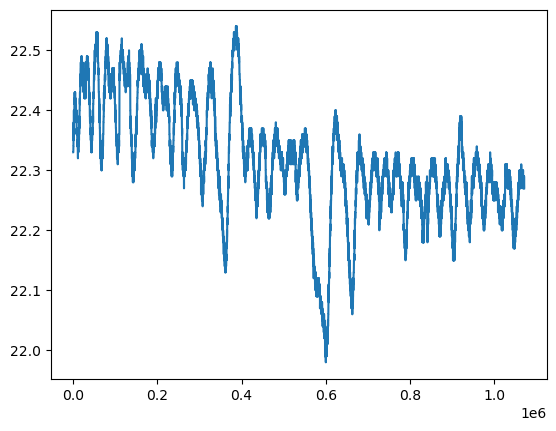

In [129]:
plt.plot(gasPressure)

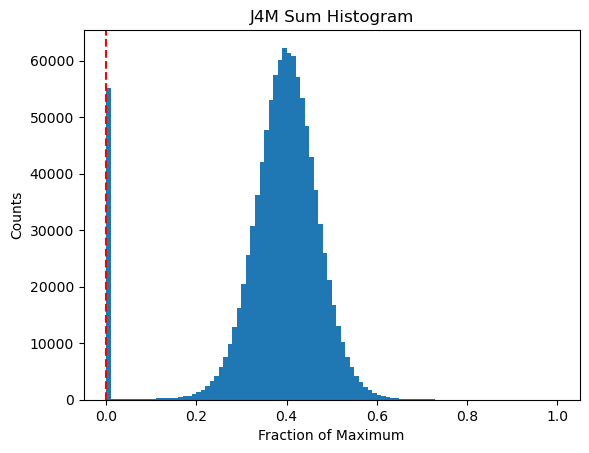

In [120]:
##########
integration_cutoff_hb = 0.2
integration_cutoff_lb = 0.05
scattering_cutoff = 0.0
##########
scattered_xrays = np.sum(azav,axis=-1)
scattered_xraysFiltered = np.sum(azavFiltered,axis=-1)

plt.hist(scattered_xrays/scattered_xrays.max(),bins=100);
plt.axvline(scattering_cutoff,color='r',linestyle='--')
plt.title('J4M Sum Histogram')
plt.xlabel('Fraction of Maximum')
plt.ylabel('Counts')
plt.show()
# Doing the actual filtering
goodIdx = (xrayOn2) & (scattered_xrays/scattered_xrays.max()>=scattering_cutoff) & (~np.isnan(scattered_xrays))
specGood = spec[goodIdx]
J4MSumFilter = scattered_xraysFiltered[goodIdx]
J4MSum = scattered_xrays[goodIdx]
gasPGood = gasPressure[goodIdx]
ipmGood = ipm[goodIdx]

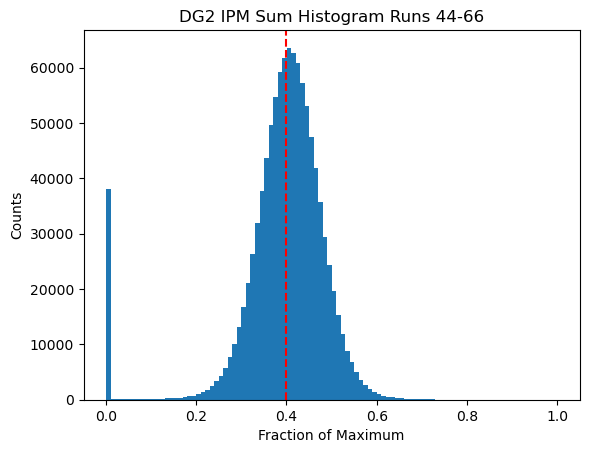

In [121]:
##########
dg2Low = 0.4
##########
plt.hist(ipmGood/ipmGood.max(),bins=100);
plt.axvline(dg2Low,color='r',linestyle='--')
plt.title(f'DG2 IPM Sum Histogram Runs {min(runNumbers)}-{max(runNumbers)}')
plt.xlabel('Fraction of Maximum')
plt.ylabel('Counts')
plt.show()

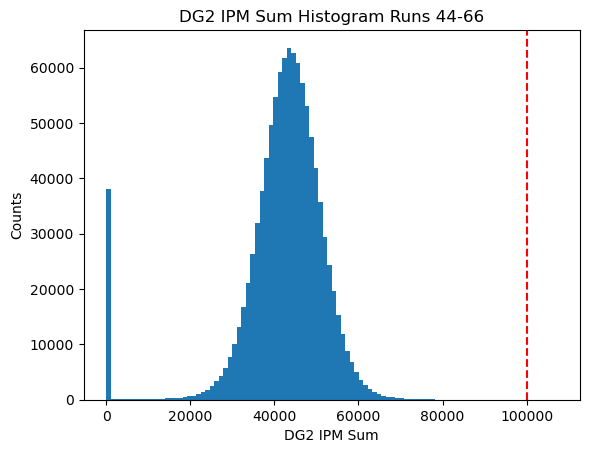

In [122]:
##########
dg2Low = 100000
##########
plt.hist(ipmGood,bins=100);
plt.axvline(dg2Low,color='r',linestyle='--')
plt.title(f'DG2 IPM Sum Histogram Runs {min(runNumbers)}-{max(runNumbers)}')
plt.xlabel('DG2 IPM Sum')
plt.ylabel('Counts')
plt.show()

[   0.25713205 -196.29231507]


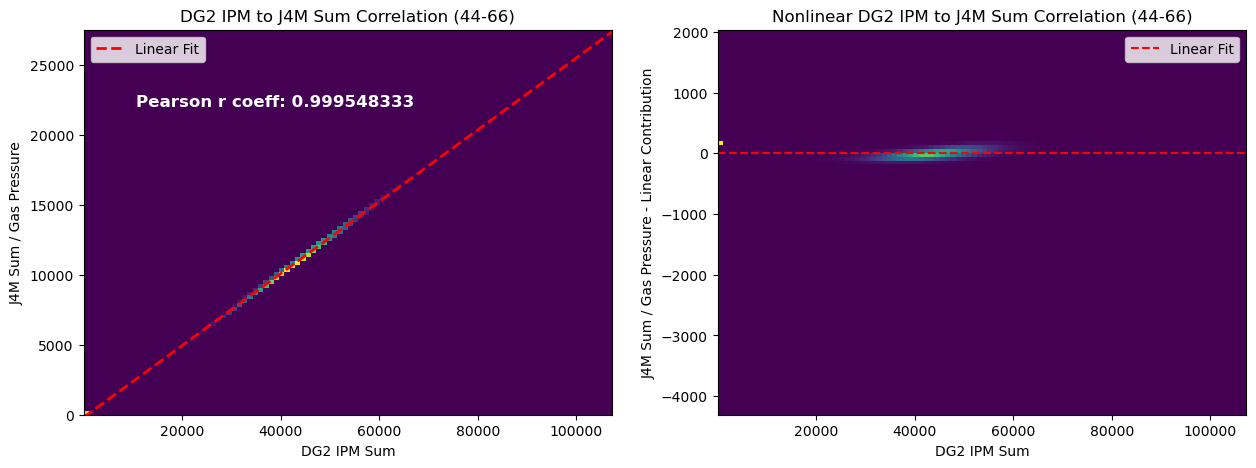

In [123]:
plt.figure(figsize=[15,5])
plt.subplot(1,2,1)
plt.title(f'DG2 IPM to J4M Sum Correlation ({min(runNumbers)}-{max(runNumbers)})')
plt.ylabel('J4M Sum / Gas Pressure')
plt.xlabel('DG2 IPM Sum')
residuals=hist2dLinFit(ipmGood,(J4MSum/gasPGood)*1000,100,linfit=True,xFrac=None,xVal=dg2Low);
plt.subplot(1,2,2)
hist, xedges, yedges, img = plt.hist2d(ipmGood,residuals,100)
plt.axhline(0,linestyle='--',color='r',label='Linear Fit')
plt.title(f'Nonlinear DG2 IPM to J4M Sum Correlation ({min(runNumbers)}-{max(runNumbers)})')
plt.ylabel('J4M Sum / Gas Pressure - Linear Contribution')
plt.xlabel('DG2 IPM Sum')
plt.legend()
plt.show();

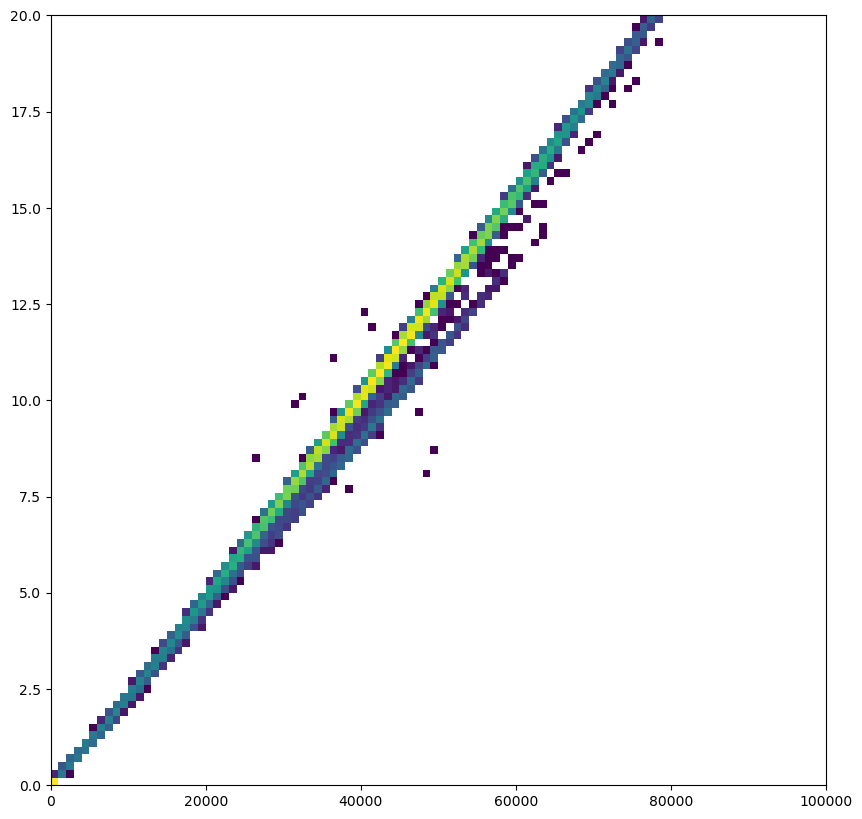

In [124]:
plt.figure(figsize=[10,10])
plt.hist2d(ipmGood,(J4MSum/gasPGood),100,norm=matplotlib.colors.LogNorm(),range=[[0,100000],[0,20]]);

/lscratch/davidjr/tmp/ipykernel_753077/3420811233.py:6: RuntimeWarning: invalid value encountered in scalar divide
  coms[i] = np.sum(xx * hist[i,:]) / np.sum(hist[i,:])


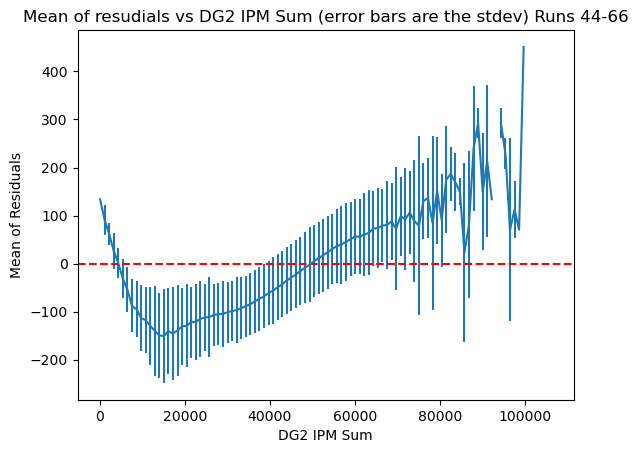

In [126]:
coms = np.zeros(hist.shape[0])
stdevs = np.zeros(hist.shape[0])
for i in range(0,hist.shape[0]-1):
    # Compute the center of mass
    xx = yedges[:-1]
    coms[i] = np.sum(xx * hist[i,:]) / np.sum(hist[i,:])

    # Compute standard deviation as sqrt(variance)
    stdevs[i] = np.sqrt(np.sum(hist[i,:] * (xx - coms[i]) ** 2) / np.sum(hist[i,:]))

plt.figure()
plt.errorbar(xedges[:-1],coms,yerr=stdevs)
plt.axhline(0, linestyle='--', color='r')
plt.xlabel('DG2 IPM Sum')
plt.ylabel('Mean of Residuals')
plt.title(f'Mean of resudials vs DG2 IPM Sum (error bars are the stdev) Runs {min(runNumbers)}-{max(runNumbers)}')
#plt.ylim(-10,0.5)
#plt.xlim(-10000,250000)
plt.show()

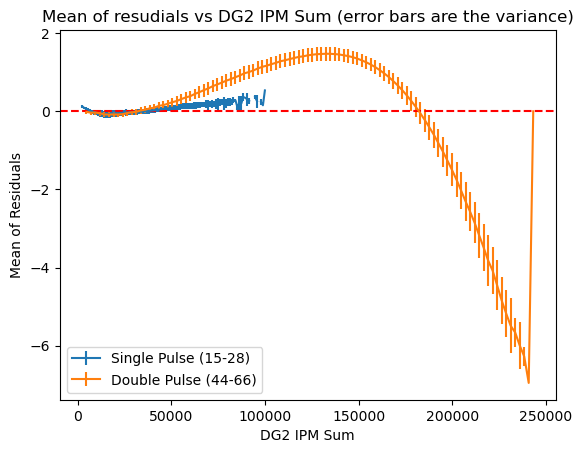

In [41]:
plt.figure()
xedges_load,coms_load,stdevs_load = np.load("pulse2Runs.npy")
plt.errorbar(xedges_load,coms_load,yerr=stdevs_load,label='Single Pulse (15-28)')
plt.errorbar(xedges[:-1],coms,yerr=stdevs,label='Double Pulse (44-66)')
plt.axhline(0, linestyle='--', color='r')
plt.xlabel('DG2 IPM Sum')
plt.ylabel('Mean of Residuals')
plt.legend()
plt.title('Mean of resudials vs DG2 IPM Sum (error bars are the variance)')
#plt.ylim(-0.2,1)
#plt.xlim(-10000,120000)
plt.show()

In [25]:
np.save("pulse2Runs.npy", (xedges[:-1], coms, stdevs))